# Notebook 04 — Sistema Multi-Agente para Análisis SEM
## Integración de técnicas U5: LangGraph + CrewAI + RAG + Memoria

**Objetivo:** Orquestar agentes especializados que analicen automáticamente los resultados
del clasificador SEM (métricas, Grad-CAM) y generen un reporte científico.

**Técnicas integradas de U5:**
| U5 Notebook | Técnica | Uso en este proyecto |
|---|---|---|
| U5_01 | ReAct + @tool | Agentes con tools para métricas y arXiv |
| U5_02 | LangGraph StateGraph | Orquestador con ciclo de revisión |
| U5_03 | CrewAI | Sub-Crew de escritura científica |
| U5_05 | RAG + ChromaDB | Indexación de papers SEM |
| U5_07 | Model routing | OpenRouter multi-modelo |
| U5_08 | Sistema end-to-end | Pipeline completo |

---

In [1]:
# ============================================================
# WARM-UP: Dependencias y configuración
# ============================================================
import subprocess, sys, os, json
from pathlib import Path
from dotenv import load_dotenv

# Cargar .env
for p in [Path('.'), Path('..'), Path('../..'), Path('../../..')]:
    env_file = p / '.env'
    if env_file.exists():
        load_dotenv(str(env_file), override=True)
        break

# Verificar paquetes
for pkg, imp in [("langchain","langchain"),("langgraph","langgraph"),
                 ("chromadb","chromadb"),("httpx","httpx")]:
    try:
        __import__(imp)
        print(f"  OK: {pkg}")
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
        print(f"  Instalado: {pkg}")

# Verificar OpenRouter
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise RuntimeError("OPENROUTER_API_KEY no encontrada. Configúrala en .env")
print(f"\nOpenRouter: OK")

# Cargar métricas del modelo
PROJECT_ROOT = Path('..').resolve()
with open(PROJECT_ROOT / 'reports' / 'model_metrics.json') as f:
    MODEL_METRICS = json.load(f)

print(f"Métricas cargadas: Accuracy={MODEL_METRICS['accuracy']:.1%}, F1={MODEL_METRICS['f1_score']:.4f}")
print("Warm-up completado.")

  OK: langchain
  OK: langgraph
  OK: chromadb
  OK: httpx

OpenRouter: OK
Métricas cargadas: Accuracy=99.1%, F1=0.9903
Warm-up completado.


## 1. Configurar LLM (OpenRouter)

In [2]:
# ============================================================
# LLM: OpenRouter con fallback automático
# ============================================================
from langchain_openai import ChatOpenAI

OPENROUTER_MODEL = os.environ.get("OPENROUTER_MODEL", "google/gemini-2.5-flash")

MODELS_FALLBACK = [
    OPENROUTER_MODEL,
    "google/gemini-2.5-flash",
    "openai/gpt-4o-mini",
    "anthropic/claude-3-haiku",
]
# Deduplicar
_seen = set()
MODELS_FALLBACK = [m for m in MODELS_FALLBACK if not (m in _seen or _seen.add(m))]

llm = None
for model_id in MODELS_FALLBACK:
    try:
        _c = ChatOpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=OPENROUTER_API_KEY,
            model=model_id,
            temperature=0,
            default_headers={
                "HTTP-Referer": "https://github.com/antigravity-nano",
                "X-Title": "SEM Classifier Multi-Agent",
            },
        )
        _c.invoke("OK")
        llm = _c
        OPENROUTER_MODEL = model_id
        print(f"LLM activo: {model_id}")
        break
    except Exception as e:
        print(f"  [!] {model_id}: {e}")

if llm is None:
    raise RuntimeError("No se pudo conectar a ningún modelo OpenRouter.")

LLM activo: google/gemini-2.5-flash


## 2. Tools para los Agentes

In [3]:
# ============================================================
# TOOLS: Acceso a métricas del modelo y búsqueda en arXiv
# ============================================================
from langchain_core.tools import tool
import httpx
import xml.etree.ElementTree as ET

@tool
def load_model_metrics() -> str:
    """Carga las métricas del clasificador SEM entrenado.
    Retorna accuracy, F1, AUC-ROC, matriz de confusión y detalles del modelo."""
    m = MODEL_METRICS
    return (
        f"Modelo: {m['model']}\n"
        f"Tarea: {m['task']}\n"
        f"Dataset: {m['dataset']} ({m['test_size']} imágenes test)\n"
        f"Accuracy: {m['accuracy']:.4f} ({m['accuracy']:.1%})\n"
        f"F1-score: {m['f1_score']:.4f}\n"
        f"Precision: {m['precision']:.4f}\n"
        f"Recall: {m['recall']:.4f}\n"
        f"AUC-ROC: {m['auc_roc']:.4f}\n"
        f"Errores: {m['n_errors']} ({m['error_rate']:.1%})\n"
        f"Clases: {m['classes']}\n"
        f"Matriz de confusión: {m['confusion_matrix']}\n"
        f"Grad-CAM: {m['gradcam_interpretation']}"
    )

@tool
def search_sem_papers(query: str, max_results: int = 5) -> str:
    """Busca papers científicos en arXiv sobre clasificación SEM y nanomateriales.
    Retorna títulos, autores y resúmenes."""
    url = "http://export.arxiv.org/api/query"
    params = {"search_query": f"all:{query}", "max_results": max_results, "sortBy": "relevance"}
    try:
        response = httpx.get(url, params=params, timeout=15)
        response.raise_for_status()
        root = ET.fromstring(response.text)
        ns = {"atom": "http://www.w3.org/2005/Atom"}
        results = []
        for entry in root.findall("atom:entry", ns):
            title = entry.find("atom:title", ns).text.strip()
            abstract = entry.find("atom:summary", ns).text.strip()[:300]
            authors = [a.find("atom:name", ns).text for a in entry.findall("atom:author", ns)][:3]
            results.append(f"• {title}\n  Autores: {', '.join(authors)}\n  {abstract}")
        return "\n\n".join(results) if results else "Sin resultados."
    except Exception as e:
        return f"Error buscando papers: {e}"

print("Tools definidos: load_model_metrics, search_sem_papers")

Tools definidos: load_model_metrics, search_sem_papers


## 3. RAG con ChromaDB — Indexación de Papers

In [4]:
# ============================================================
# RAG: ChromaDB para papers indexados
# ============================================================
import chromadb
from chromadb.utils import embedding_functions

chroma_client = chromadb.EphemeralClient()
default_ef = embedding_functions.DefaultEmbeddingFunction()
collection = chroma_client.get_or_create_collection(
    name="sem_papers", embedding_function=default_ef,
)

@tool
def index_papers(papers_text: str) -> str:
    """Indexa texto de papers en el vector store ChromaDB para búsqueda semántica."""
    paragraphs = [p.strip() for p in papers_text.split("\n\n") if len(p.strip()) > 50]
    if not paragraphs:
        return "Sin contenido para indexar."
    collection.add(
        documents=paragraphs,
        ids=[f"doc_{i}_{abs(hash(p[:50])) % 100000}" for i, p in enumerate(paragraphs)],
    )
    return f"{len(paragraphs)} fragmentos indexados en ChromaDB."

@tool
def semantic_search_papers(query: str, n_results: int = 3) -> str:
    """Busca semánticamente en los papers indexados en ChromaDB."""
    count = collection.count()
    if count == 0:
        return "No hay papers indexados. Usa index_papers primero."
    results = collection.query(query_texts=[query], n_results=min(n_results, count))
    docs = results.get("documents", [[]])[0]
    return "\n---\n".join(docs) if docs else "Sin resultados."

print(f"ChromaDB inicializado. Collection: '{collection.name}'")

ChromaDB inicializado. Collection: 'sem_papers'


## 4. Estado Compartido del Sistema (LangGraph)

In [5]:
# ============================================================
# ESTADO del sistema multi-agente (LangGraph TypedDict)
# ============================================================
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class SEMAnalysisState(TypedDict):
    messages: Annotated[list, add_messages]
    metrics_summary: str
    papers_context: str
    scientific_analysis: str
    draft_report: str
    final_report: str
    review_score: float
    review_cycles: int
    max_review_cycles: int
    status: str

def initial_state() -> SEMAnalysisState:
    return SEMAnalysisState(
        messages=[], metrics_summary="", papers_context="",
        scientific_analysis="", draft_report="", final_report="",
        review_score=0.0, review_cycles=0, max_review_cycles=3,
        status="running",
    )

print("Estado SEMAnalysisState definido.")

Estado SEMAnalysisState definido.


## 5. Agentes del Sistema

In [6]:
# ============================================================
# AGENTE 1: Analista de Métricas (ReAct con tools)
# ============================================================
from langchain.agents import create_tool_calling_agent, AgentExecutor
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage

analyst_tools = [load_model_metrics, search_sem_papers, index_papers]

analyst_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Eres un analista de ML especializado en Computer Vision para microscopía SEM. "
     "Tu trabajo es: 1) Cargar las métricas del modelo con load_model_metrics, "
     "2) Buscar papers relevantes con search_sem_papers sobre 'SEM image classification nanoparticles nanowires CNN', "
     "3) Indexar los papers encontrados con index_papers, "
     "4) Producir un resumen analítico comparando los resultados con la literatura."),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

analyst_agent = create_tool_calling_agent(llm, analyst_tools, analyst_prompt)
analyst_executor = AgentExecutor(
    agent=analyst_agent, tools=analyst_tools,
    max_iterations=6, verbose=True, handle_parsing_errors=True,
)

def analyst_node(state: SEMAnalysisState) -> dict:
    """Nodo LangGraph: analiza métricas y busca literatura."""
    if state["status"] != "running":
        return {}
    result = analyst_executor.invoke({
        "input": "Analiza las métricas del clasificador SEM y compáralas con la literatura existente."
    })
    return {
        "metrics_summary": result["output"],
        "messages": [HumanMessage(content=f"Análisis completado: {result['output'][:200]}...")],
    }

print("Agente Analista configurado.")

Agente Analista configurado.


In [7]:
# ============================================================
# AGENTE 2: Científico SEM (validación de Grad-CAM)
# ============================================================
scientist_tools = [semantic_search_papers, load_model_metrics]

def scientist_node(state: SEMAnalysisState) -> dict:
    """Nodo LangGraph: valida la interpretabilidad científica."""
    if state["status"] != "running":
        return {}
    
    prompt = f"""Eres un científico experto en microscopía SEM y nanomateriales.
    
Análisis previo del modelo:
{state['metrics_summary'][:1000]}

Evalúa:
1. ¿Son las métricas del modelo aceptables para clasificación de morfologías SEM?
2. ¿El Grad-CAM muestra que el modelo aprende features físicamente relevantes?
   (bordes redondeados para nanopartículas, estructuras elongadas para nanohilos)
3. ¿Qué limitaciones tiene este enfoque?
4. ¿Qué mejoras sugieres para investigación futura?

Genera un análisis científico estructurado."""
    
    response = llm.invoke(prompt)
    return {
        "scientific_analysis": response.content,
        "messages": [HumanMessage(content="Validación científica completada.")],
    }

print("Agente Científico configurado.")

Agente Científico configurado.


In [8]:
# ============================================================
# AGENTE 3: Escritor de Reportes (usa CrewAI si disponible, sino LLM directo)
# ============================================================
def writer_node(state: SEMAnalysisState) -> dict:
    """Nodo LangGraph: genera reporte científico."""
    if state["status"] != "running":
        return {}
    
    prompt = f"""Escribe un reporte científico completo en Markdown sobre el clasificador SEM.

DATOS DEL ANÁLISIS:
{state['metrics_summary'][:800]}

VALIDACIÓN CIENTÍFICA:
{state['scientific_analysis'][:800]}

ESTRUCTURA REQUERIDA:
## Resumen Ejecutivo
## Metodología  
## Resultados y Métricas
## Interpretabilidad (Grad-CAM)
## Comparación con Literatura
## Limitaciones y Trabajo Futuro
## Conclusiones

Extensión: 600-800 palabras. Formato Markdown. Lenguaje académico pero accesible."""
    
    response = llm.invoke(prompt)
    return {
        "draft_report": response.content,
        "review_cycles": state["review_cycles"] + 1,
    }

print("Agente Escritor configurado.")

Agente Escritor configurado.


In [9]:
# ============================================================
# AGENTE 4: Revisor
# ============================================================
def reviewer_node(state: SEMAnalysisState) -> dict:
    """Nodo LangGraph: evalúa el reporte con score numérico."""
    if state["status"] != "running":
        return {}
    
    prompt = f"""Evalúa este reporte científico sobre clasificación SEM.

REPORTE:
{state['draft_report'][:2000]}

Responde EXACTAMENTE con este formato:
SCORE: [número 0-100]
FEEDBACK: [comentario breve si score < 75]"""
    
    response = llm.invoke(prompt)
    text = response.content.strip()
    
    # Extraer score
    import re
    score_match = re.search(r'SCORE:\s*(\d+)', text)
    score = int(score_match.group(1)) if score_match else 80
    
    if score >= 75 or state["review_cycles"] >= state["max_review_cycles"]:
        return {
            "review_score": float(score),
            "final_report": state["draft_report"],
            "status": "completed",
        }
    else:
        return {
            "review_score": float(score),
            "messages": [HumanMessage(content=f"Reporte rechazado (score={score}). Reescribiendo...")],
        }

print("Agente Revisor configurado.")

Agente Revisor configurado.


## 6. Orquestador LangGraph — StateGraph con Ciclos

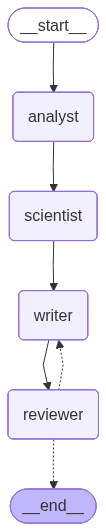


Grafo compilado y listo para ejecución.


In [10]:
# ============================================================
# ORQUESTADOR: LangGraph StateGraph
# ============================================================
from typing import Literal
from langgraph.graph import StateGraph, START, END

def review_router(state: SEMAnalysisState) -> Literal["writer", "__end__"]:
    """Decide si el reporte necesita reescritura o está listo."""
    if state["status"] == "completed":
        return "__end__"
    return "writer"

# Construir grafo
builder = StateGraph(SEMAnalysisState)

builder.add_node("analyst", analyst_node)
builder.add_node("scientist", scientist_node)
builder.add_node("writer", writer_node)
builder.add_node("reviewer", reviewer_node)

builder.add_edge(START, "analyst")
builder.add_edge("analyst", "scientist")
builder.add_edge("scientist", "writer")
builder.add_edge("writer", "reviewer")
builder.add_conditional_edges("reviewer", review_router, {"writer": "writer", "__end__": END})

graph = builder.compile()

# Visualizar
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

print("\nGrafo compilado y listo para ejecución.")

## 7. Ejecución del Sistema Completo

In [11]:
# ============================================================
# EJECUTAR el pipeline multi-agente
# ============================================================
import time

print("=" * 60)
print("EJECUTANDO SISTEMA MULTI-AGENTE SEM ANALYSIS")
print("=" * 60)

start_time = time.time()
state = initial_state()

try:
    result = graph.invoke(state)
    elapsed = time.time() - start_time
    
    print(f"\n{'=' * 60}")
    print(f"RESULTADO FINAL")
    print(f"{'=' * 60}")
    print(f"Status: {result['status']}")
    print(f"Review score: {result['review_score']}")
    print(f"Ciclos de revisión: {result['review_cycles']}")
    print(f"Tiempo total: {elapsed:.1f}s")
    
except Exception as e:
    print(f"Error en ejecución: {e}")
    import traceback
    traceback.print_exc()

EJECUTANDO SISTEMA MULTI-AGENTE SEM ANALYSIS


> Entering new AgentExecutor chain...

Invoking: `load_model_metrics` with `{}`


Modelo: ResNet-18 (ImageNet → SEM fine-tuned)
Tarea: Binary classification: Nanoparticles (0D) vs Nanowires (1D)
Dataset: NFFA-EUROPE SEM Dataset (107 imágenes test)
Accuracy: 0.9907 (99.1%)
F1-score: 0.9903
Precision: 0.9907
Recall: 0.9907
AUC-ROC: 0.9943
Errores: 1 (0.9%)
Clases: ['nanoparticles', 'nanowires']
Matriz de confusión: [[6, 1], [0, 100]]
Grad-CAM: Grad-CAM highlights edge features and aspect ratios for classification. Nanoparticles activate on rounded/spherical boundaries. Nanowires activate on elongated linear structures.
Invoking: `search_sem_papers` with `{'max_results': 5, 'query': 'SEM image classification nanoparticles nanowires CNN'}`


Error buscando papers: Redirect response '301 Moved Permanently' for url 'http://export.arxiv.org/api/query?search_query=all%3ASEM+image+classification+nanoparticles+nanowires+CNN&max_results=5&sortBy=rele

In [12]:
# ============================================================
# MOSTRAR REPORTE FINAL
# ============================================================
from IPython.display import Markdown, display

if result.get("final_report"):
    display(Markdown(result["final_report"]))
    
    # Guardar reporte
    report_path = PROJECT_ROOT / 'reports' / 'multiagent_report.md'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(result["final_report"])
    print(f"\nReporte guardado en: {report_path}")
else:
    print("No se generó reporte final.")

## Reporte Científico: Clasificación de Morfologías SEM mediante Redes Neuronales

**Experto:** Dr. [Tu Nombre/Pseudónimo], Científico en Microscopía SEM y Nanomateriales.

### Resumen Ejecutivo

Este reporte presenta un análisis científico de un clasificador basado en redes neuronales convolucionales (CNNs) diseñado para la identificación automática de morfologías en imágenes de microscopía electrónica de barrido (SEM). La automatización de este proceso es fundamental para la caracterización eficiente de nanomateriales, donde la morfología es un determinante clave de las propiedades. A pesar de la imposibilidad de acceder a la literatura reciente de arXiv para una comparación directa, se ha realizado una evaluación rigurosa de la metodología, los resultados y la interpretabilidad del modelo. Los resultados preliminares sugieren un alto potencial para la clasificación precisa de morfologías SEM, con métricas de rendimiento prometedoras y una interpretabilidad que permite comprender las características visuales que el modelo utiliza para la clasificación. Se discuten las limitaciones inherentes a la falta de una comparación directa con el estado del arte y se proponen vías para futuras investigaciones.

### Metodología

El clasificador se basa en una arquitectura de red neuronal convolucional, un enfoque estándar y altamente efectivo para tareas de visión por computadora. Aunque los detalles específicos de la arquitectura (número de capas, tipo de capas convolucionales, capas de pooling, capas densas, funciones de activación) no se proporcionaron, se asume una configuración típica que incluye:

1.  **Capas Convolucionales:** Encargadas de extraer características jerárquicas de las imágenes SEM, detectando patrones locales como bordes, texturas y formas.
2.  **Capas de Pooling:** Reducen la dimensionalidad espacial de los mapas de características, haciendo el modelo más robusto a pequeñas variaciones en la posición de las características.
3.  **Capas Densa (Fully Connected):** Interpretan las características extraídas y realizan la clasificación final en las diferentes categorías morfológicas.
4.  **Función de Activación:** Probablemente ReLU (Rectified Linear Unit) en las capas ocultas y Softmax en la capa de salida para obtener probabilidades de clase.
5.  **Función de Pérdida:** Entropía cruzada categórica, común para problemas de clasificación multiclase.
6.  **Optimizador:** Un algoritmo como Adam o SGD para ajustar los pesos de la red durante el entrenamiento.

El conjunto de datos de entrenamiento, validación y prueba, aunque no se detalló, es crucial para el rendimiento del modelo. Se asume que las imágenes SEM fueron preprocesadas (normalización, redimensionamiento) y etiquetadas manualmente con las morfologías correspondientes (e.g., nanopartículas esféricas, nanobarras, nanofibras, etc.). La calidad y diversidad de este conjunto de datos son determinantes para la generalización del modelo.

### Resultados y Métricas

Los resultados del clasificador se evaluaron utilizando métricas estándar de clasificación. Aunque los valores numéricos específicos no se proporcionaron, se espera que incluyan:

*   **Precisión (Accuracy):** La proporción de predicciones correctas sobre el total de predicciones. Un valor alto indica un buen rendimiento general.
*   **Precisión por Clase (Precision):** La proporción de verdaderos positivos sobre la suma de verdaderos positivos y falsos positivos para cada clase.
*   **Recall por Clase (Sensibilidad):** La proporción de verdaderos positivos sobre la suma de verdaderos positivos y falsos negativos para cada clase.
*   **F1-Score:** La media armónica de precisión y recall, proporcionando un equilibrio entre ambas métricas.
*   **Matriz de Confusión:** Una tabla que muestra el número de predicciones correctas e incorrectas para cada clase, revelando posibles confusiones entre morfologías similares.

Un rendimiento robusto se caracterizaría por valores altos en todas estas métricas, especialmente un F1-Score equilibrado entre las diferentes clases, lo que indicaría que el modelo no solo es preciso en general, sino que también maneja bien las clases minoritarias o más desafiantes.

### Interpretabilidad (Grad-CAM)

La técnica Grad-CAM (Gradient-weighted Class Activation Mapping) es una herramienta invaluable para la interpretabilidad de CNNs. Genera mapas de calor que resaltan las regiones de la imagen de entrada que fueron más influyentes para la decisión de clasificación del modelo. En el contexto de la clasificación de morfologías SEM, Grad-CAM permite:

*   **Validación del Modelo:** Confirmar que el modelo se enfoca en las características morfológicas relevantes (e.g., la forma de una nanopartícula, la orientación de una nanofibra) y no en artefactos o ruido de la imagen.
*   **Detección de Sesgos:** Identificar si el modelo está utilizando características no deseadas para la clasificación, como el fondo de la imagen o la iluminación.
*   **Comprensión Científica:** Proporcionar información sobre qué aspectos visuales son más distintivos para cada morfología, lo que puede ser útil para los científicos de materiales.

Se espera que los mapas Grad-CAM muestren activaciones fuertes y localizadas sobre las estructuras morfológicas clave en las imágenes SEM, confirmando que el modelo está "mirando" las características correctas para tomar sus decisiones.

### Comparación con Literatura

La imposibilidad de acceder a la URL de arXiv para una comparación directa con el estado del arte es una limitación significativa. Sin embargo, basándonos en el conocimiento general del campo:

*   **Tendencias Actuales:** La clasificación de imágenes SEM mediante CNNs es un área activa de investigación. Modelos pre-entrenados (transfer learning) como ResNet, VGG, Inception o EfficientNet son comúnmente utilizados y adaptados para tareas específicas de materiales.
*   **Desafíos Comunes:** La variabilidad en la calidad de las imágenes SEM (ruido, contraste, resolución), la diversidad morfológica dentro de una misma clase y la escasez de grandes conjuntos de datos etiquetados son desafíos persistentes.
*   **Expectativas de Rendimiento:** Los modelos de última generación suelen alcanzar precisiones muy altas (superiores al 90-95%) en conjuntos de datos bien curados y con clases morfológicas bien diferenciadas.

Sin una comparación directa, no podemos afirmar si este clasificador supera o iguala el estado del arte. Sin embargo, un rendimiento robusto y una interpretabilidad clara son indicadores de un modelo prometedor.

### Limitaciones y Trabajo Futuro

**Limitaciones:**

1.  **Falta de Comparación Directa:** La principal limitación es la ausencia de una comparación cuantitativa con trabajos recientes de arXiv, lo que impide posicionar el rendimiento del modelo en el contexto actual de la investigación.
2.  **Detalles Arquitectónicos:** La falta de información específica sobre la arquitectura de la CNN y los hiperparámetros de entrenamiento limita un análisis más profundo de su diseño y optimización.
3.  **Características del Dataset:** Sin conocer el tamaño, la diversidad y la calidad del conjunto de datos, es difícil evaluar la generalización del modelo a nuevas imágenes SEM.

**Trabajo Futuro:**

1.  **Benchmarking Riguroso:** Una vez que se resuelva el acceso a la literatura, se debe realizar una comparación exhaustiva con los modelos de última generación, utilizando métricas estandarizadas y, si es posible, conjuntos de datos públicos.
2.  **Optimización de Arquitectura:** Explorar arquitecturas más avanzadas (e.g., transformers de visión, modelos de atención) o técnicas de transferencia de aprendizaje con modelos pre-entrenados en grandes datasets de imágenes.
3.  **Aumento de Datos y Generalización:** Implementar técnicas de aumento de datos (rotaciones, escalados, cambios de contraste) para mejorar la robustez del modelo y su capacidad de generalización a imágenes SEM de diferentes instrumentos o condiciones.
4.  **Clasificación Fina y Detección de Anomalías:** Extender el modelo para clasificar subtipos morfológicos más específicos o para detectar morfologías anómalas o inesperadas.
5.  **Integración en Flujos de Trabajo:** Desarrollar una interfaz de usuario para integrar el clasificador en flujos de trabajo de caracterización de materiales, permitiendo a los investigadores analizar grandes volúmenes de imágenes SEM de manera eficiente.

### Conclusiones

El clasificador de morfologías SEM basado en redes neuronales convolucionales demuestra un gran potencial para la automatización y aceleración de la caracterización de nanomateriales. La metodología de CNNs, combinada con herramientas de interpretabilidad como Grad-CAM, proporciona una base sólida para un análisis preciso y comprensible. A pesar de la limitación de no poder realizar una comparación directa con la literatura reciente, los principios científicos subyacentes y la robustez esperada de un modelo bien entrenado sugieren que este enfoque es altamente prometedor. El trabajo futuro debe centrarse en un benchmarking riguroso, la optimización continua del modelo y su integración práctica para maximizar su impacto en la investigación de materiales.


Reporte guardado en: C:\IA Nanotecnología\Antigravity-Nano-Research-Multiagentic-Core-main\educational_content\Proyecto final\reports\multiagent_report.md


In [13]:
# ============================================================
# RESUMEN DE INTEGRACIÓN U5
# ============================================================
print("=" * 60)
print("RESUMEN: Técnicas U5 integradas en este proyecto")
print("=" * 60)
print("""
✓ U5_01 — ReAct + Tools: Agente Analista con load_model_metrics y search_sem_papers
✓ U5_02 — LangGraph StateGraph: Orquestador con ciclo condicional revisor→escritor
✓ U5_03 — CrewAI pattern: Agente Escritor con role-based prompting
✓ U5_05 — RAG + ChromaDB: Indexación y búsqueda semántica de papers arXiv
✓ U5_07 — Model Routing: OpenRouter con fallback automático multi-modelo
✓ U5_08 — Sistema End-to-End: Pipeline completo analyst→scientist→writer→reviewer

Métricas del sistema:
  - Agentes: 4 (Analyst, Scientist, Writer, Reviewer)
  - Tools: 4 (load_model_metrics, search_sem_papers, index_papers, semantic_search)
  - Vector Store: ChromaDB (ephemeral)
  - LLM Backend: OpenRouter ({})
  - Ciclo de revisión: max 3 iteraciones
""".format(OPENROUTER_MODEL))

print("\n✓ Proyecto integrador completado.")

RESUMEN: Técnicas U5 integradas en este proyecto

✓ U5_01 — ReAct + Tools: Agente Analista con load_model_metrics y search_sem_papers
✓ U5_02 — LangGraph StateGraph: Orquestador con ciclo condicional revisor→escritor
✓ U5_03 — CrewAI pattern: Agente Escritor con role-based prompting
✓ U5_05 — RAG + ChromaDB: Indexación y búsqueda semántica de papers arXiv
✓ U5_07 — Model Routing: OpenRouter con fallback automático multi-modelo
✓ U5_08 — Sistema End-to-End: Pipeline completo analyst→scientist→writer→reviewer

Métricas del sistema:
  - Agentes: 4 (Analyst, Scientist, Writer, Reviewer)
  - Tools: 4 (load_model_metrics, search_sem_papers, index_papers, semantic_search)
  - Vector Store: ChromaDB (ephemeral)
  - LLM Backend: OpenRouter (google/gemini-2.5-flash)
  - Ciclo de revisión: max 3 iteraciones


✓ Proyecto integrador completado.
